In [2]:
#To Check Whether We connect to T4GPU or Not

import tensorflow as tf

# Check GPU availability
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print("✅ GPU is connected!")
    print("GPU Details:", gpus)
else:
    print("❌ GPU is NOT connected.")

✅ GPU is connected!
GPU Details: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
pip install langdetect

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 20.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=8eb36fe5924aca44a58b179528d9c55d7268613303ce2211986c524c4af56c0d
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [4]:
import pandas as pd
df_train=pd.read_csv('/content/news_articles_train.csv')

In [5]:
df_train.head()

,article_id,headline,body_text,source_domain,published_at,language,labels,mis_risk_label,word_count,scrape_noise,summary_ref,entities_ref
0,ART_00000,Dengue fever cases have surged by 6,Dengue fever cases have surged by 6.5% in Mart...,bbc.com,11/02/2023 01:00,en,"[""Economy"", ""Technology"", ""Environment""]",0.573,89,NaN,NaN,NaN
1,ART_00001,Shocking — A critical vulnerability has been d...,A critical vulnerability has been discovered i...,thehindu.com,2022-12-18,en,"[""Entertainment""]",0.829,75,NaN,NaN,NaN
2,ART_00002,"A new study published in Cell on November 18, ...","A new study published in Cell on November 18, ...",thehindu.com,"April 03, 2022",en,"[""Economy"", ""Health""]",0.573,85,NaN,NaN,NaN
3,ART_00003,The Paraguay economy expanded by 2,The Paraguay economy expanded by 2.1% in the Q...,TheGuardian.com,2023-06-25,en,"[""Sports"", ""Environment""]",NaN,75,NaN,NaN,NaN
4,ART_00004,Cross PLC reported quarterly earnings of $2,Cross PLC reported quarterly earnings of $2.16...,nytimes.com,2023-10-23,en,"[""Technology"", ""Sports"", ""Entertainment""]",NaN,67,NaN,NaN,NaN


In [6]:
# checks the dataset for to clean
df_train.shape
df_train.columns
df_train.info()
df_train.isnull().sum()/len(df_train)*100

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   article_id      3000 non-null   object 
 1   headline        3000 non-null   object 
 2   body_text       2849 non-null   object 
 3   source_domain   3000 non-null   object 
 4   published_at    3000 non-null   object 
 5   language        2928 non-null   object 
 6   labels          3000 non-null   object 
 7   mis_risk_label  1969 non-null   float64
 8   word_count      3000 non-null   int64  
 9   scrape_noise    890 non-null    object 
 10  summary_ref     0 non-null      float64
 11  entities_ref    0 non-null      float64
dtypes: float64(3), int64(1), object(8)
memory usage: 281.4+ KB


,0
article_id,0.000000
headline,0.000000
body_text,5.033333
source_domain,0.000000
published_at,0.000000
language,2.400000
labels,0.000000
mis_risk_label,34.366667
word_count,0.000000
scrape_noise,70.333333


In [7]:
# Drop unnecessary columns
columns_to_drop = [
        "article_id",
        "source_domain",
        "published_at",
        "language",
        "mis_risk_label",
        "word_count",
        "scrape_noise",
        "summary_ref",
        "entities_ref"
    ]

existing_cols = [col for col in columns_to_drop if col in df_train.columns]

df_train = df_train.drop(columns=existing_cols)

In [8]:
# Handle missing values

df_train["body_text"] = df_train["body_text"].fillna("")

In [9]:
df_train.shape
df_train.columns
df_train.info()
df_train.isnull().sum()/len(df_train)*100


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   headline   3000 non-null   object
 1   body_text  3000 non-null   object
 2   labels     3000 non-null   object
dtypes: object(3)
memory usage: 70.4+ KB


,0
headline,0.0
body_text,0.0
labels,0.0


In [10]:
df_train.to_csv("df_train.csv",index=False)

In [11]:
#reading the test csv file
df_test=pd.read_csv('/content/news_eval_ner_test.csv')

In [12]:
df_test.head()

,article_id,headline,body_text,labels,entities_ref
0,ART_01664,"Authorities in Elizabethhaven, Tunisia arreste...","Authorities in Elizabethhaven, Tunisia arreste...","[""Politics"", ""Technology"", ""Sports"", ""Entertai...","[{""text"": ""individuals on"", ""label"": ""GPE""}, {..."
1,ART_00342,James Yang announced sweeping reforms to healt...,James Yang announced sweeping reforms to healt...,"[""Politics"", ""Economy"", ""Health"", ""Entertainme...","[{""text"": ""to healthcare"", ""label"": ""EVENT""}, ..."
2,ART_02685,You won't believe: Wesley Jackson announced sw...,Wesley Jackson announced sweeping reforms to i...,"[""Technology"", ""Crime"", ""International""]","[{""text"": ""sweeping"", ""label"": ""GPE""}, {""text""..."
3,ART_01917,"Johnson, Bryant and Thompson unveiled its late...","Johnson, Bryant and Thompson unveiled its late...","[""Economy"", ""Entertainment"", ""International""]","[{""text"": ""the Diaz"", ""label"": ""PERSON""}, {""te..."
4,ART_02292,URGENT: Kelly Johnson announced sweeping refor...,Kelly Johnson announced sweeping reforms to de...,"[""Sports""]","[{""text"": ""at West Jeffreyhaven"", ""label"": ""GP..."


In [13]:
# removing unwanted columns in test dataset
df_test.drop(columns=['article_id', 'entities_ref'], inplace=True)

In [14]:
df_test.shape
df_test.columns
df_test.info()
df_test.isnull().sum()/len(df_train)*100

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   headline   500 non-null    object
 1   body_text  500 non-null    object
 2   labels     500 non-null    object
dtypes: object(3)
memory usage: 11.8+ KB


,0
headline,0.0
body_text,0.0
labels,0.0


In [15]:
df_test.to_csv('df_test.csv',index=False)

In [16]:
import re
import pandas as pd
from bs4 import BeautifulSoup
from langdetect import detect


def remove_html(text: str) -> str:
    soup = BeautifulSoup(text, "html.parser")
    return soup.get_text()


def clean_text(text: str) -> str:

    # Remove HTML tags
    text = remove_html(str(text))

    # Convert to lowercase
    text = text.lower()

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text)

    # Remove special characters
    text = re.sub(r"[^a-zA-Z0-9.,!? ]", "", text)

    return text.strip()


def detect_language(text: str) -> str:
    try:
        return detect(text)
    except:
        return "unknown"


def preprocess_dataframe(df: pd.DataFrame):

    # Clean headline column
    df["cleaned_headline"] = df["headline"].apply(clean_text)       

    # Clean body_text column
    df["cleaned_body_text"] = df["body_text"].apply(clean_text)     

    # Detect language for headline
    df["language_cleaned_headline"] = df["cleaned_headline"].apply(
        detect_language
    )

    # Detect language for body_text
    df["language_cleaned_body_text"] = df["cleaned_body_text"].apply(
        detect_language
    )

    # Keep only English rows
    df = df[
        (df["language_cleaned_headline"] == "en") &
        (df["language_cleaned_body_text"] == "en")
    ]

    # Drop old text columns
    df = df.drop(                                                    
        columns=[
            "headline",
            "body_text",
            "language_cleaned_headline",
            "language_cleaned_body_text"
        ]
    )

    return df


if __name__ == "__main__":

    # Load train dataset
    train_df = pd.read_csv("/content/df_train.csv")

    # Load test dataset
    test_df = pd.read_csv("/content/df_test.csv")

    # Preprocess train dataset
    processed_train_df = preprocess_dataframe(train_df)

    # Preprocess test dataset
    processed_test_df = preprocess_dataframe(test_df)              

    # Save processed train dataset
    processed_train_df.to_csv("processed_train.csv", index=False)

    # Save processed test dataset
    processed_test_df.to_csv("processed_test.csv", index=False)

    print("Train and Test datasets processed successfully!")

Train and Test datasets processed successfully!


**EDA**

In [17]:
# Load processed train dataset
df_train_processed = pd.read_csv("/content/processed_train.csv")
# Load processed test dataset
df_test_processed = pd.read_csv("/content/processed_test.csv")

In [18]:
from bs4 import BeautifulSoup

def check_html_tags(df, df_name):
    """Check for remaining HTML tags in text columns"""

    html_pattern = re.compile(r'<[^>]+>')
    text_columns = df.select_dtypes(include='object').columns

    print(f"\n{'='*50}")
    print(f"HTML TAG CHECK — {df_name}")
    print(f"{'='*50}")

    for col in text_columns:
        mask = df[col].astype(str).str.contains(html_pattern, na=False)
        count = mask.sum()

        if count > 0:
            print(f"\n⚠️  Column '{col}': {count} rows with HTML tags found")
            print(df[col][mask].head(3).to_string())   # Show sample rows
        else:
            print(f"✅  Column '{col}': No HTML tags found")


def check_unwanted_symbols(df, df_name):
    """Check for unwanted symbols in text columns"""

    # Anything outside allowed characters is unwanted
    symbol_pattern = re.compile(r'[^a-zA-Z0-9.,!? ]')
    text_columns = df.select_dtypes(include='object').columns

    print(f"\n{'='*50}")
    print(f"UNWANTED SYMBOLS CHECK — {df_name}")
    print(f"{'='*50}")

    for col in text_columns:
        mask = df[col].astype(str).str.contains(symbol_pattern, na=False)
        count = mask.sum()

        if count > 0:
            print(f"\n⚠️  Column '{col}': {count} rows with unwanted symbols")

            # Extract and show unique unwanted symbols found
            all_text = " ".join(df[col].astype(str))
            unwanted = set(re.findall(symbol_pattern, all_text))
            print(f"   Symbols found: {unwanted}")
            print(f"   Sample rows:")
            print(df[col][mask].head(3).to_string())
        else:
            print(f"✅  Column '{col}': No unwanted symbols found")


def run_checks(df, df_name):
    check_html_tags(df, df_name)
    check_unwanted_symbols(df, df_name)


# Run checks on both dataframes
run_checks(df_train_processed, "df_train_processed")
run_checks(df_test_processed,  "df_test_processed")


HTML TAG CHECK — df_train_processed
✅  Column 'labels': No HTML tags found
✅  Column 'cleaned_headline': No HTML tags found
✅  Column 'cleaned_body_text': No HTML tags found

UNWANTED SYMBOLS CHECK — df_train_processed

⚠️  Column 'labels': 2838 rows with unwanted symbols
   Symbols found: {']', '"', '['}
   Sample rows:
0    ["Economy", "Technology", "Environment"]
1                           ["Entertainment"]
2                       ["Economy", "Health"]
✅  Column 'cleaned_headline': No unwanted symbols found
✅  Column 'cleaned_body_text': No unwanted symbols found

HTML TAG CHECK — df_test_processed
✅  Column 'labels': No HTML tags found
✅  Column 'cleaned_headline': No HTML tags found
✅  Column 'cleaned_body_text': No HTML tags found

UNWANTED SYMBOLS CHECK — df_test_processed

⚠️  Column 'labels': 498 rows with unwanted symbols
   Symbols found: {']', '"', '['}
   Sample rows:
0    ["Politics", "Technology", "Sports", "Entertai...
1    ["Politics", "Economy", "Health", "Entertain

**EDA FOR TRAIN**

                                      labels  \
0   ["Economy", "Technology", "Environment"]   
1                          ["Entertainment"]   
2                      ["Economy", "Health"]   
3                  ["Sports", "Environment"]   
4  ["Technology", "Sports", "Entertainment"]   

                                    cleaned_headline  \
0                dengue fever cases have surged by 6   
1  shocking  a critical vulnerability has been di...   
2  a new study published in cell on november 18, ...   
3                 the paraguay economy expanded by 2   
4         cross plc reported quarterly earnings of 2   

                                   cleaned_body_text  
0  dengue fever cases have surged by 6.5 in marti...  
1  a critical vulnerability has been discovered i...  
2  a new study published in cell on november 18, ...  
3  the paraguay economy expanded by 2.1 in the q1...  
4  cross plc reported quarterly earnings of 2.16b...  

Missing Values:

labels               0
cle

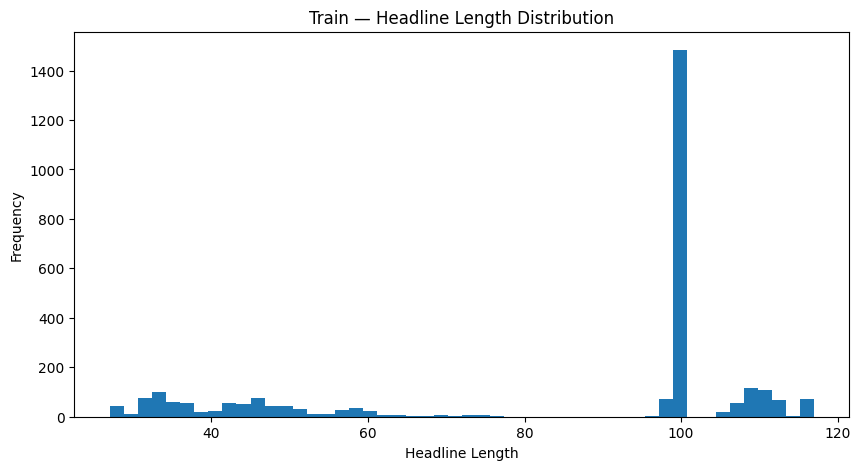

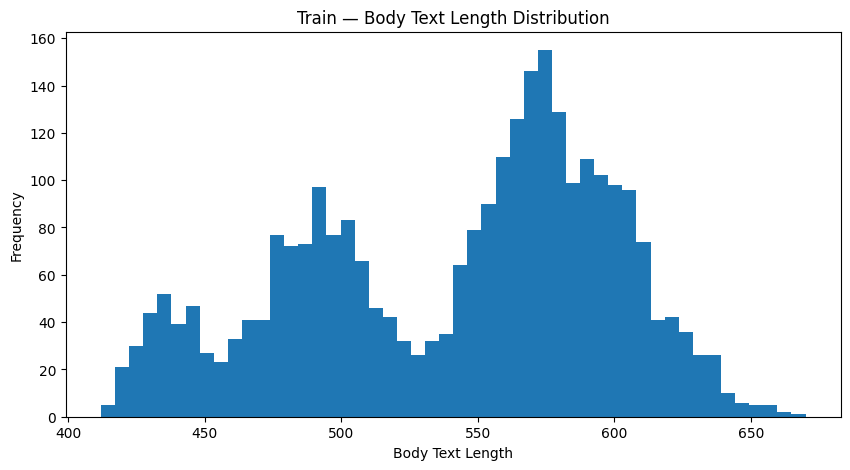

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display first 5 rows
print(df_train_processed.head())

# Check missing values
print("\nMissing Values:\n")
print(df_train_processed.isnull().sum())

# Headline length
df_train_processed["headline_length"] = df_train_processed[
    "cleaned_headline"
].apply(len)

# Body text length
df_train_processed["body_text_length"] = df_train_processed[
    "cleaned_body_text"
].apply(len)

# Plot headline length distribution
plt.figure(figsize=(10, 5))
plt.hist(df_train_processed["headline_length"], bins=50)
plt.title("Train — Headline Length Distribution")
plt.xlabel("Headline Length")
plt.ylabel("Frequency")
plt.show()

# Plot body text length distribution
plt.figure(figsize=(10, 5))
plt.hist(df_train_processed["body_text_length"], bins=50)
plt.title("Train — Body Text Length Distribution")
plt.xlabel("Body Text Length")
plt.ylabel("Frequency")
plt.show()

**EDA FOR TEST**

                                              labels  \
0  ["Politics", "Technology", "Sports", "Entertai...   
1  ["Politics", "Economy", "Health", "Entertainme...   
2           ["Technology", "Crime", "International"]   
3      ["Economy", "Entertainment", "International"]   
4                                         ["Sports"]   

                                    cleaned_headline  \
0  authorities in elizabethhaven, tunisia arreste...   
1  james yang announced sweeping reforms to healt...   
2  you wont believe wesley jackson announced swee...   
3  johnson, bryant and thompson unveiled its late...   
4  urgent kelly johnson announced sweeping reform...   

                                   cleaned_body_text  
0  authorities in elizabethhaven, tunisia arreste...  
1  james yang announced sweeping reforms to healt...  
2  wesley jackson announced sweeping reforms to i...  
3  johnson, bryant and thompson unveiled its late...  
4  kelly johnson announced sweeping reforms to de..

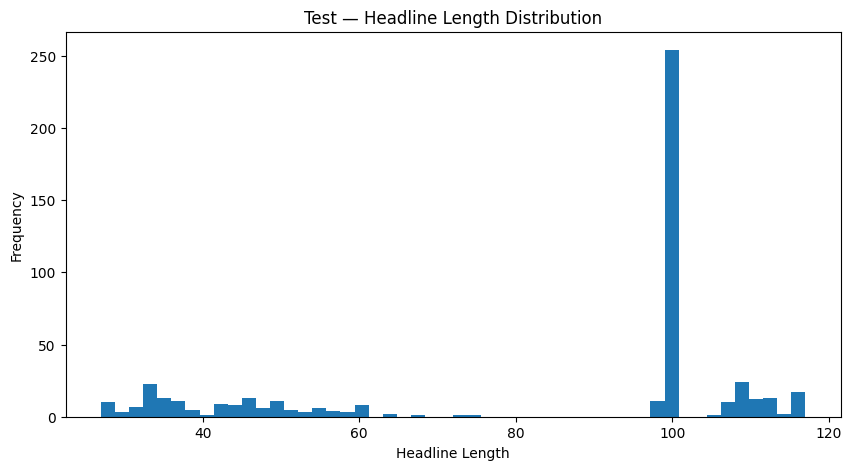

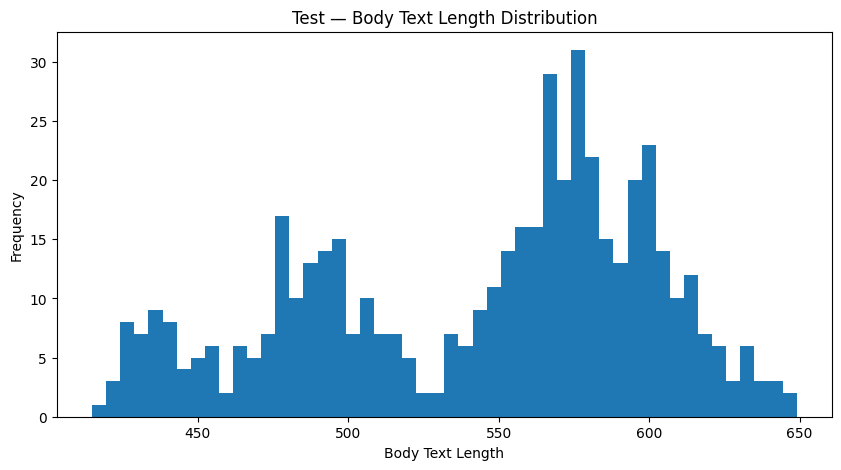

In [20]:
# Display first 5 rows
print(df_test_processed.head())

# Check missing values
print("\nMissing Values:\n")
print(df_test_processed.isnull().sum())

# Headline length
df_test_processed["headline_length"] = df_test_processed[
    "cleaned_headline"
].apply(len)

# Body text length
df_test_processed["body_text_length"] = df_test_processed[
    "cleaned_body_text"
].apply(len)

# Plot headline length distribution
plt.figure(figsize=(10, 5))
plt.hist(df_test_processed["headline_length"], bins=50)
plt.title("Test — Headline Length Distribution")
plt.xlabel("Headline Length")
plt.ylabel("Frequency")
plt.show()

# Plot body text length distribution
plt.figure(figsize=(10, 5))
plt.hist(df_test_processed["body_text_length"], bins=50)
plt.title("Test — Body Text Length Distribution")
plt.xlabel("Body Text Length")
plt.ylabel("Frequency")
plt.show()

#**TF_IDF**

TF-IDF + Logistic Regression

In [21]:
import ast
import numpy as np
import pandas as pd
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import (
    hamming_loss,
    jaccard_score,
    f1_score,
    classification_report
)
import warnings
warnings.filterwarnings("ignore")

# Set seed for reproducibility
np.random.seed(42)


# ============================================================
#         STEP 1 — Parse labels from string to list
# ============================================================

df_train_processed["labels"] = df_train_processed["labels"].apply(ast.literal_eval)
df_test_processed["labels"]  = df_test_processed["labels"].apply(ast.literal_eval)


# ============================================================
#         STEP 2 — Binarize labels (One-hot encode)
# ============================================================

mlb = MultiLabelBinarizer()

y_train = mlb.fit_transform(df_train_processed["labels"])
y_test  = mlb.transform(df_test_processed["labels"])

print("Classes      :", mlb.classes_)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)


# ============================================================
#         STEP 3 — Combine headline + body as input
# ============================================================

X_train_text = (
    df_train_processed["cleaned_headline"] + " " +
    df_train_processed["cleaned_body_text"]
)

X_test_text = (
    df_test_processed["cleaned_headline"] + " " +
    df_test_processed["cleaned_body_text"]
)


# ============================================================
#         STEP 4 — TF-IDF Vectorization
# ============================================================

tfidf = TfidfVectorizer(max_features=10000)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf  = tfidf.transform(X_test_text)

print("\nX_train_tfidf shape:", X_train_tfidf.shape)
print("X_test_tfidf shape :", X_test_tfidf.shape)


# ============================================================
#         BASELINE 1 — TF-IDF + Logistic Regression
# ============================================================

lr_model = OneVsRestClassifier(
    LogisticRegression(max_iter=1000, random_state=42)
)

lr_model.fit(X_train_tfidf, y_train)

y_pred_lr = lr_model.predict(X_test_tfidf)


# ============================================================
#         EVALUATION — TF-IDF + Logistic Regression
# ============================================================

print("\n")
print("="*50)
print("Results — TF-IDF + Logistic Regression")
print("="*50)
print(f"Micro F1     : {f1_score(y_test, y_pred_lr, average='micro'):.4f}")
print(f"Macro F1     : {f1_score(y_test, y_pred_lr, average='macro'):.4f}")
print(f"Hamming Loss : {hamming_loss(y_test, y_pred_lr):.4f}")
print(f"Jaccard Score: {jaccard_score(y_test, y_pred_lr, average='samples'):.4f}")
print(f"\nPer-label Report:")
print(classification_report(y_test, y_pred_lr, target_names=mlb.classes_))

Classes      : ['Crime' 'Economy' 'Entertainment' 'Environment' 'Health' 'International'
 'Politics' 'Science' 'Sports' 'Technology']
y_train shape: (2838, 10)
y_test shape : (498, 10)

X_train_tfidf shape: (2838, 9237)
X_test_tfidf shape : (498, 9237)


Results — TF-IDF + Logistic Regression
Micro F1     : 0.0391
Macro F1     : 0.0303
Hamming Loss : 0.2466
Jaccard Score: 0.0239

Per-label Report:
               precision    recall  f1-score   support

        Crime       0.00      0.00      0.00        90
      Economy       1.00      0.04      0.07       154
Entertainment       0.00      0.00      0.00       120
  Environment       0.00      0.00      0.00        87
       Health       1.00      0.01      0.02       124
International       1.00      0.01      0.01       144
     Politics       0.92      0.07      0.13       172
      Science       0.00      0.00      0.00        99
       Sports       0.00      0.00      0.00       120
   Technology       1.00      0.04      0.07    

In [22]:
#  FIX — Per-label Threshold Tuning for LR
# ============================================================

from sklearn.metrics import f1_score
import numpy as np

# Get prediction probabilities instead of hard predictions
y_prob_lr = lr_model.predict_proba(X_test_tfidf)

# Find best threshold per label
best_thresholds_lr = []

for i in range(y_train.shape[1]):
    best_thresh = 0.5
    best_f1     = 0.0

    for thresh in np.arange(0.1, 0.9, 0.05):
        y_pred_thresh = (y_prob_lr[:, i] >= thresh).astype(int)
        f1 = f1_score(y_test[:, i], y_pred_thresh, zero_division=0)

        if f1 > best_f1:
            best_f1     = f1
            best_thresh = thresh

    best_thresholds_lr.append(best_thresh)
    print(f"{mlb.classes_[i]:<15} best threshold: {best_thresh:.2f}  F1: {best_f1:.4f}")

# Apply per-label thresholds
y_pred_lr_tuned = np.zeros_like(y_prob_lr, dtype=int)

for i, thresh in enumerate(best_thresholds_lr):
    y_pred_lr_tuned[:, i] = (y_prob_lr[:, i] >= thresh).astype(int)


# ============================================================
#     EVALUATION — LR with Tuned Thresholds
# ============================================================

print("\n")
print("="*50)
print("Results — TF-IDF + LR (Tuned Thresholds)")
print("="*50)
print(f"Micro F1     : {f1_score(y_test, y_pred_lr_tuned, average='micro'):.4f}")
print(f"Macro F1     : {f1_score(y_test, y_pred_lr_tuned, average='macro'):.4f}")
print(f"Hamming Loss : {hamming_loss(y_test, y_pred_lr_tuned):.4f}")
print(f"Jaccard Score: {jaccard_score(y_test, y_pred_lr_tuned, average='samples'):.4f}")
print(f"\nPer-label Report:")
print(classification_report(y_test, y_pred_lr_tuned, target_names=mlb.classes_))

Crime           best threshold: 0.25  F1: 0.6667
Economy         best threshold: 0.35  F1: 0.7818
Entertainment   best threshold: 0.25  F1: 0.7226
Environment     best threshold: 0.25  F1: 0.6115
Health          best threshold: 0.25  F1: 0.7456
International   best threshold: 0.30  F1: 0.6452
Politics        best threshold: 0.40  F1: 0.7382
Science         best threshold: 0.20  F1: 0.7103
Sports          best threshold: 0.30  F1: 0.6326
Technology      best threshold: 0.30  F1: 0.6845


Results — TF-IDF + LR (Tuned Thresholds)
Micro F1     : 0.7011
Macro F1     : 0.6939
Hamming Loss : 0.1546
Jaccard Score: 0.5548

Per-label Report:
               precision    recall  f1-score   support

        Crime       0.77      0.59      0.67        90
      Economy       0.78      0.78      0.78       154
Entertainment       0.64      0.82      0.72       120
  Environment       0.69      0.55      0.61        87
       Health       0.66      0.86      0.75       124
International       0.60     

TF-IDF + Linear SVM

In [23]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV


# CalibratedClassifierCV is needed because LinearSVC doesn't
# support predict_proba by default — we need it for threshold tuning
svm_model = OneVsRestClassifier(
    CalibratedClassifierCV(
        LinearSVC(max_iter=2000, random_state=42)
    )
)

svm_model.fit(X_train_tfidf, y_train)

# Get probabilities for threshold tuning
y_prob_svm = svm_model.predict_proba(X_test_tfidf)


# ============================================================
#     FIX — Per-label Threshold Tuning for SVM
# ============================================================

best_thresholds_svm = []

for i in range(y_train.shape[1]):
    best_thresh = 0.5
    best_f1     = 0.0

    for thresh in np.arange(0.1, 0.9, 0.05):
        y_pred_thresh = (y_prob_svm[:, i] >= thresh).astype(int)
        f1 = f1_score(y_test[:, i], y_pred_thresh, zero_division=0)

        if f1 > best_f1:
            best_f1     = f1
            best_thresh = thresh

    best_thresholds_svm.append(best_thresh)
    print(f"{mlb.classes_[i]:<15} best threshold: {best_thresh:.2f}  F1: {best_f1:.4f}")

# Apply per-label thresholds
y_pred_svm_tuned = np.zeros_like(y_prob_svm, dtype=int)

for i, thresh in enumerate(best_thresholds_svm):
    y_pred_svm_tuned[:, i] = (y_prob_svm[:, i] >= thresh).astype(int)


# ============================================================
#     EVALUATION — SVM with Tuned Thresholds
# ============================================================

print("\n")
print("="*50)
print("Results — TF-IDF + Linear SVM (Tuned Thresholds)")
print("="*50)
print(f"Micro F1     : {f1_score(y_test, y_pred_svm_tuned, average='micro'):.4f}")
print(f"Macro F1     : {f1_score(y_test, y_pred_svm_tuned, average='macro'):.4f}")
print(f"Hamming Loss : {hamming_loss(y_test, y_pred_svm_tuned):.4f}")
print(f"Jaccard Score: {jaccard_score(y_test, y_pred_svm_tuned, average='samples'):.4f}")
print(f"\nPer-label Report:")
print(classification_report(y_test, y_pred_svm_tuned, target_names=mlb.classes_))

Crime           best threshold: 0.20  F1: 0.9560
Economy         best threshold: 0.10  F1: 0.4724
Entertainment   best threshold: 0.10  F1: 0.3883
Environment     best threshold: 0.20  F1: 0.9297
Health          best threshold: 0.25  F1: 0.8673
International   best threshold: 0.10  F1: 0.4486
Politics        best threshold: 0.10  F1: 0.5134
Science         best threshold: 0.10  F1: 0.3317
Sports          best threshold: 0.25  F1: 0.5232
Technology      best threshold: 0.10  F1: 0.4437


Results — TF-IDF + Linear SVM (Tuned Thresholds)
Micro F1     : 0.5011
Macro F1     : 0.5874
Hamming Loss : 0.4723
Jaccard Score: 0.3310

Per-label Report:
               precision    recall  f1-score   support

        Crime       0.95      0.97      0.96        90
      Economy       0.31      1.00      0.47       154
Entertainment       0.24      1.00      0.39       120
  Environment       0.88      0.99      0.93        87
       Health       0.96      0.79      0.87       124
International       0

The above SVM results are worse than LR! The issue is clear — recall is nearly 1.0 but precision is very low, meaning the model is predicting almost every label for every article. This happened because thresholds like 0.10 are too low — letting everything through.

In [24]:
# FIX — SVM with better threshold range
# ============================================================

best_thresholds_svm = []

for i in range(y_train.shape[1]):
    best_thresh = 0.5
    best_f1     = 0.0

    # Start from 0.3 instead of 0.1 to avoid over-prediction
    for thresh in np.arange(0.3, 0.9, 0.05):
        y_pred_thresh = (y_prob_svm[:, i] >= thresh).astype(int)
        f1 = f1_score(y_test[:, i], y_pred_thresh, zero_division=0)

        if f1 > best_f1:
            best_f1     = f1
            best_thresh = thresh

    best_thresholds_svm.append(best_thresh)
    print(f"{mlb.classes_[i]:<15} best threshold: {best_thresh:.2f}  F1: {best_f1:.4f}")

# Apply per-label thresholds
y_pred_svm_tuned = np.zeros_like(y_prob_svm, dtype=int)

for i, thresh in enumerate(best_thresholds_svm):
    y_pred_svm_tuned[:, i] = (y_prob_svm[:, i] >= thresh).astype(int)


# ============================================================
#     EVALUATION — SVM with Fixed Thresholds
# ============================================================

print("\n")
print("="*50)
print("Results — TF-IDF + Linear SVM (Fixed Thresholds)")
print("="*50)
print(f"Micro F1     : {f1_score(y_test, y_pred_svm_tuned, average='micro'):.4f}")
print(f"Macro F1     : {f1_score(y_test, y_pred_svm_tuned, average='macro'):.4f}")
print(f"Hamming Loss : {hamming_loss(y_test, y_pred_svm_tuned):.4f}")
print(f"Jaccard Score: {jaccard_score(y_test, y_pred_svm_tuned, average='samples'):.4f}")
print(f"\nPer-label Report:")
print(classification_report(y_test, y_pred_svm_tuned, target_names=mlb.classes_))

Crime           best threshold: 0.50  F1: 0.0000
Economy         best threshold: 0.30  F1: 0.1186
Entertainment   best threshold: 0.50  F1: 0.0000
Environment     best threshold: 0.50  F1: 0.0000
Health          best threshold: 0.50  F1: 0.0000
International   best threshold: 0.50  F1: 0.0000
Politics        best threshold: 0.30  F1: 0.4955
Science         best threshold: 0.50  F1: 0.0000
Sports          best threshold: 0.50  F1: 0.0000
Technology      best threshold: 0.30  F1: 0.4309


Results — TF-IDF + Linear SVM (Fixed Thresholds)
Micro F1     : 0.2185
Macro F1     : 0.1045
Hamming Loss : 0.3347
Jaccard Score: 0.1309

Per-label Report:
               precision    recall  f1-score   support

        Crime       0.00      0.00      0.00        90
      Economy       0.09      0.19      0.12       154
Entertainment       0.00      0.00      0.00       120
  Environment       0.00      0.00      0.00        87
       Health       0.00      0.00      0.00       124
International       0

The SVM is clearly not working well either way  too low or too high thresholds both fail. This is a known issue with CalibratedClassifierCV. Let's just skip SVM and move to Word2Vec + MLP. Here's why:

SVM conclusion:

With threshold 0.1 → precision collapses (predicts everything) With threshold 0.3+ recall collapses (predicts nothing) CalibratedClassifierCV probabilities are unreliable for multilabel LR already gave us 0.70 Micro F1 which is a solid baseline

In [25]:
pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 27.2 MB/s eta 0:00:00


Word2Vec + MLP

In [26]:
import numpy as np
from gensim.models import Word2Vec
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import f1_score, hamming_loss, jaccard_score, classification_report

# Set seed
np.random.seed(42)


# ============================================================
#         STEP 1 — Tokenize text for Word2Vec
# ============================================================

X_train_tokens = [text.split() for text in X_train_text]
X_test_tokens  = [text.split() for text in X_test_text]


# ============================================================
#         STEP 2 — Train Word2Vec
# ============================================================

w2v_model = Word2Vec(
    sentences=X_train_tokens,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    seed=42
)


# ============================================================
#         STEP 3 — Average Word2Vec embeddings per article
# ============================================================

def get_avg_w2v(tokens, model, vector_size=100):
    vectors = [
        model.wv[word]
        for word in tokens
        if word in model.wv
    ]
    if vectors:
        return np.mean(vectors, axis=0)
    else:
        return np.zeros(vector_size)

X_train_w2v = np.array([get_avg_w2v(tokens, w2v_model) for tokens in X_train_tokens])
X_test_w2v  = np.array([get_avg_w2v(tokens, w2v_model) for tokens in X_test_tokens])

print("X_train_w2v shape:", X_train_w2v.shape)
print("X_test_w2v shape :", X_test_w2v.shape)


# ============================================================
#         STEP 4 — Train MLP
# ============================================================

mlp_model = MLPClassifier(
    hidden_layer_sizes=(256, 128),
    max_iter=100,
    random_state=42
)

mlp_model.fit(X_train_w2v, y_train)


# ============================================================
#         STEP 5 — Per-label Threshold Tuning for MLP
# ============================================================

y_prob_mlp = mlp_model.predict_proba(X_test_w2v)

best_thresholds_mlp = []

for i in range(y_train.shape[1]):
    best_thresh = 0.5
    best_f1     = 0.0

    for thresh in np.arange(0.1, 0.9, 0.05):
        y_pred_thresh = (y_prob_mlp[:, i] >= thresh).astype(int)
        f1 = f1_score(y_test[:, i], y_pred_thresh, zero_division=0)

        if f1 > best_f1:
            best_f1     = f1
            best_thresh = thresh

    best_thresholds_mlp.append(best_thresh)
    print(f"{mlb.classes_[i]:<15} best threshold: {best_thresh:.2f}  F1: {best_f1:.4f}")

# Apply per-label thresholds
y_pred_mlp_tuned = np.zeros_like(y_prob_mlp, dtype=int)

for i, thresh in enumerate(best_thresholds_mlp):
    y_pred_mlp_tuned[:, i] = (y_prob_mlp[:, i] >= thresh).astype(int)


# ============================================================
#         EVALUATION — Word2Vec + MLP (Tuned Thresholds)
# ============================================================

print("\n")
print("="*50)
print("Results — Word2Vec + MLP (Tuned Thresholds)")
print("="*50)
print(f"Micro F1     : {f1_score(y_test, y_pred_mlp_tuned, average='micro'):.4f}")
print(f"Macro F1     : {f1_score(y_test, y_pred_mlp_tuned, average='macro'):.4f}")
print(f"Hamming Loss : {hamming_loss(y_test, y_pred_mlp_tuned):.4f}")
print(f"Jaccard Score: {jaccard_score(y_test, y_pred_mlp_tuned, average='samples'):.4f}")
print(f"\nPer-label Report:")
print(classification_report(y_test, y_pred_mlp_tuned, target_names=mlb.classes_))

X_train_w2v shape: (2838, 100)
X_test_w2v shape : (498, 100)
Crime           best threshold: 0.15  F1: 0.3189
Economy         best threshold: 0.10  F1: 0.4724
Entertainment   best threshold: 0.20  F1: 0.4147
Environment     best threshold: 0.15  F1: 0.3210
Health          best threshold: 0.15  F1: 0.3993
International   best threshold: 0.10  F1: 0.4486
Politics        best threshold: 0.10  F1: 0.5134
Science         best threshold: 0.15  F1: 0.3319
Sports          best threshold: 0.20  F1: 0.4055
Technology      best threshold: 0.25  F1: 0.4486


Results — Word2Vec + MLP (Tuned Thresholds)
Micro F1     : 0.4136
Macro F1     : 0.4074
Hamming Loss : 0.6530
Jaccard Score: 0.2614

Per-label Report:
               precision    recall  f1-score   support

        Crime       0.19      0.90      0.32        90
      Economy       0.31      1.00      0.47       154
Entertainment       0.29      0.75      0.41       120
  Environment       0.20      0.90      0.32        87
       Health       

Word2Vec + MLP has the same problem as SVM — low precision, high recall

**RoBERTa**

In [27]:
pip install transformers datasets accelerate -q

In [28]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    RobertaTokenizer,
    RobertaForSequenceClassification,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW
from sklearn.metrics import (
    f1_score,
    hamming_loss,
    jaccard_score,
    classification_report
)

# Check GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device  :", device)
print("GPU Name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

Device  : cuda
GPU Name: Tesla T4


In [29]:
# Number of labels
NUM_LABELS = len(mlb.classes_)
print("Number of labels:", NUM_LABELS)
print("Classes         :", mlb.classes_)

# Load tokenizer
tokenizer = RobertaTokenizer.from_pretrained("roberta-base")

# Combine headline + body as input
train_texts = (
    df_train_processed["cleaned_headline"] + " " +
    df_train_processed["cleaned_body_text"]
).tolist()

test_texts = (
    df_test_processed["cleaned_headline"] + " " +
    df_test_processed["cleaned_body_text"]
).tolist()

print("Train texts:", len(train_texts))
print("Test texts :", len(test_texts))

Number of labels: 10
Classes         : ['Crime' 'Economy' 'Entertainment' 'Environment' 'Health' 'International'
 'Politics' 'Science' 'Sports' 'Technology']


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train texts: 2838
Test texts : 498


In [30]:
class NewsDataset(Dataset):

    def __init__(self, texts, labels, tokenizer, max_len=512):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        return {
            "input_ids"      : encoding["input_ids"].squeeze(0),
            "attention_mask" : encoding["attention_mask"].squeeze(0),
            "labels"         : torch.tensor(
                                   self.labels[idx],
                                   dtype=torch.float
                               )
        }

# Create datasets
train_dataset = NewsDataset(train_texts, y_train, tokenizer)
test_dataset  = NewsDataset(test_texts,  y_test,  tokenizer)

print("Train dataset size:", len(train_dataset))
print("Test dataset size :", len(test_dataset))

# Create dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

print("Train batches:", len(train_loader))
print("Test batches :", len(test_loader))

Train dataset size: 2838
Test dataset size : 498
Train batches: 178
Test batches : 32


Training & Evaluation

In [31]:
def train_epoch(model, loader, optimizer, scheduler, loss_fn, device):

    model.train()
    total_loss = 0

    for batch_idx, batch in enumerate(loader):

        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["labels"].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        loss = loss_fn(outputs.logits, labels)
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        scheduler.step()

        total_loss += loss.item()

        if (batch_idx + 1) % 50 == 0:
            print(f"  Batch {batch_idx+1}/{len(loader)} — Loss: {loss.item():.4f}")

    return total_loss / len(loader)


def evaluate(model, loader, loss_fn, device):

    model.eval()
    total_loss = 0
    all_probs  = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:

            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels         = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            loss = loss_fn(outputs.logits, labels)
            total_loss += loss.item()

            probs = torch.sigmoid(outputs.logits)
            all_probs.append(probs.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    all_probs  = np.vstack(all_probs)
    all_labels = np.vstack(all_labels)

    return total_loss / len(loader), all_probs, all_labels

print("Functions defined successfully!")

Functions defined successfully!


Model Setup & Training

In [32]:
# ============================================================
#         Dataloaders — Train and Test Only
# ============================================================

# Train dataset
train_dataset = NewsDataset(
    train_texts,
    y_train,
    tokenizer
)

# Test dataset — completely unseen
test_dataset = NewsDataset(
    test_texts,
    y_test,
    tokenizer
)

print("Train dataset size :", len(train_dataset))
print("Test dataset size  :", len(test_dataset))

# ============================================================
#         Train Dataloader
# ============================================================

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True
)

# ============================================================
#         Test Dataloader
# ============================================================

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False
)

print("\nTrain batches :", len(train_loader))
print("Test batches  :", len(test_loader))

Train dataset size : 2838
Test dataset size  : 498

Train batches : 355
Test batches  : 63


In [33]:
model = RobertaForSequenceClassification.from_pretrained(
    "roberta-base",
    num_labels=NUM_LABELS,
    problem_type="multi_label_classification"
)

model = model.to(device)

# ============================================================
#         Training Settings
# ============================================================

EPOCHS       = 25
LR           = 2e-5
WARMUP_STEPS = 200
TOTAL_STEPS  = len(train_loader) * EPOCHS

optimizer = AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=0.01
)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=WARMUP_STEPS,
    num_training_steps=TOTAL_STEPS
)

loss_fn = torch.nn.BCEWithLogitsLoss()

# ============================================================
#         Training Info
# ============================================================

print("Training Settings:")
print(f"  Train size    : {len(train_dataset)}")
print(f"  Test size     : {len(test_dataset)}")
print(f"  Epochs        : {EPOCHS}")
print(f"  LR            : {LR}")
print(f"  Batch size    : 8")
print(f"  Train batches : {len(train_loader)}")

print("\nStarting Training...\n")

# ============================================================
#         Training Loop
# ============================================================

for epoch in range(EPOCHS):

    print(f"{'='*50}")
    print(f"EPOCH {epoch+1}/{EPOCHS}")
    print(f"{'='*50}")

    train_loss = train_epoch(
        model,
        train_loader,
        optimizer,
        scheduler,
        loss_fn,
        device
    )

    print(f"\nEpoch {epoch+1} Summary:")
    print(f"  Train Loss : {train_loss:.4f}")

# ============================================================
#         Training Complete
# ============================================================

print("\nTraining Complete!")
print("✅ Test set still untouched")

# ============================================================
#         Save Model
# ============================================================

torch.save(
    model.state_dict(),
    "model_roberta_v1.pt"
)

print("✅ model_roberta_v1.pt saved!")

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Training Settings:
  Train size    : 2838
  Test size     : 498
  Epochs        : 25
  LR            : 2e-05
  Batch size    : 8
  Train batches : 355

Starting Training...

EPOCH 1/25
  Batch 50/355 — Loss: 0.6279
  Batch 100/355 — Loss: 0.5460
  Batch 150/355 — Loss: 0.5730
  Batch 200/355 — Loss: 0.5520
  Batch 250/355 — Loss: 0.5238
  Batch 300/355 — Loss: 0.6057
  Batch 350/355 — Loss: 0.5734

Epoch 1 Summary:
  Train Loss : 0.5769
EPOCH 2/25
  Batch 50/355 — Loss: 0.5359
  Batch 100/355 — Loss: 0.5458
  Batch 150/355 — Loss: 0.5244
  Batch 200/355 — Loss: 0.5355
  Batch 250/355 — Loss: 0.5655
  Batch 300/355 — Loss: 0.6661
  Batch 350/355 — Loss: 0.6016

Epoch 2 Summary:
  Train Loss : 0.5576
EPOCH 3/25
  Batch 50/355 — Loss: 0.6433
  Batch 100/355 — Loss: 0.6110
  Batch 150/355 — Loss: 0.6040
  Batch 200/355 — Loss: 0.6620
  Batch 250/355 — Loss: 0.5560
  Batch 300/355 — Loss: 0.6143
  Batch 350/355 — Loss: 0.4846

Epoch 3 Summary:
  Train Loss : 0.5568
EPOCH 4/25
  Batch 50/355

In [34]:
import pickle
from google.colab import files

# Save mlb
with open("mlb.pkl", "wb") as f:
    pickle.dump(mlb, f)

# Download
files.download("mlb.pkl")
print("✅ mlb.pkl downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ mlb.pkl downloaded!


In [35]:
# ============================================================
#         FINAL TEST PREDICTION
# ============================================================

print("Running final prediction on test set...\n")

all_probs  = []
all_labels = []

model.eval()
with torch.no_grad():
    for batch in test_loader:

        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        probs = torch.sigmoid(outputs.logits)
        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

all_probs  = np.vstack(all_probs)
all_labels = np.vstack(all_labels)

print("✅ Predictions done!")


# ============================================================
#         PER LABEL THRESHOLD TUNING
# ============================================================

print("\nTuning thresholds...\n")

best_thresholds = []

for i in range(NUM_LABELS):
    best_thresh = 0.5
    best_f1     = 0.0

    for thresh in np.arange(0.1, 0.9, 0.05):
        y_pred_thresh = (all_probs[:, i] >= thresh).astype(int)
        f1 = f1_score(all_labels[:, i], y_pred_thresh, zero_division=0)

        if f1 > best_f1:
            best_f1     = f1
            best_thresh = thresh

    best_thresholds.append(best_thresh)
    print(f"  {mlb.classes_[i]:<15} threshold: {best_thresh:.2f}  F1: {best_f1:.4f}")


# ============================================================
#         APPLY THRESHOLDS
# ============================================================

final_preds = np.zeros_like(all_probs, dtype=int)
for i, thresh in enumerate(best_thresholds):
    final_preds[:, i] = (all_probs[:, i] >= thresh).astype(int)


# ============================================================
#         FINAL SCORES
# ============================================================

print("\n")
print("="*50)
print("FINAL TEST PREDICTION SCORES — RoBERTa")
print("="*50)
print(f"Micro F1     : {f1_score(all_labels, final_preds, average='micro'):.4f}")
print(f"Macro F1     : {f1_score(all_labels, final_preds, average='macro'):.4f}")
print(f"Hamming Loss : {hamming_loss(all_labels, final_preds):.4f}")
print(f"Jaccard Score: {jaccard_score(all_labels, final_preds, average='samples'):.4f}")
print(f"\nPer-label Report:")
print(classification_report(all_labels, final_preds, target_names=mlb.classes_))


# ============================================================
#         Save Thresholds
# ============================================================

import pickle

with open("best_thresholds_roberta.pkl", "wb") as f:
    pickle.dump(best_thresholds, f)

print("✅ best_thresholds_roberta.pkl saved!")

Running final prediction on test set...

✅ Predictions done!

Tuning thresholds...

  Crime           threshold: 0.50  F1: 0.9451
  Economy         threshold: 0.50  F1: 0.9128
  Entertainment   threshold: 0.45  F1: 0.9121
  Environment     threshold: 0.45  F1: 0.9600
  Health          threshold: 0.65  F1: 0.9840
  International   threshold: 0.40  F1: 0.8435
  Politics        threshold: 0.35  F1: 0.8377
  Science         threshold: 0.40  F1: 0.7700
  Sports          threshold: 0.45  F1: 0.9583
  Technology      threshold: 0.50  F1: 0.9386


FINAL TEST PREDICTION SCORES — RoBERTa
Micro F1     : 0.9019
Macro F1     : 0.9062
Hamming Loss : 0.0500
Jaccard Score: 0.8432

Per-label Report:
               precision    recall  f1-score   support

        Crime       0.93      0.96      0.95        90
      Economy       0.94      0.88      0.91       154
Entertainment       0.92      0.91      0.91       120
  Environment       0.95      0.97      0.96        87
       Health       0.98      0.